# AR Baseline Models — Growth (ISM) & Inflation (CPI)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.stattools import adfuller



pd.set_option("display.precision", 3)
plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

## 1. Load data

Two sheets: `Growth` (ISM New Orders) and `Inflation` (CPI level). 

In [2]:
xl = pd.ExcelFile("AR_Model_Data.xlsx")
growth = xl.parse("Growth"); growth.columns = ["date", "ism"]
infl = xl.parse("Inflation"); infl.columns = ["date", "cpi"]

growth["date"] = pd.to_datetime(growth["date"])
infl["date"] = pd.to_datetime(infl["date"])
growth = growth.set_index("date").sort_index()
infl = infl.set_index("date").sort_index()

ism = growth["ism"].dropna(); ism.index.freq = "ME"
cpi = infl["cpi"].dropna(); cpi.index.freq = "ME"

print(f"ISM: {ism.index[0].date()} to {ism.index[-1].date()}  ({len(ism)} obs)")
print(f"CPI: {cpi.index[0].date()} to {cpi.index[-1].date()}  ({len(cpi)} obs)")
ism.tail()


ISM: 1996-09-30 to 2026-08-31  (360 obs)
CPI: 1947-01-31 to 2026-08-31  (956 obs)


date
2026-04-30    54.1
2026-05-31    56.8
2026-06-30    56.0
2026-07-31    56.7
2026-08-31    53.7
Freq: ME, Name: ism, dtype: float64

## 2. Stationarity check

An AR model assumes the series is (roughly) stationary: mean-reverting,
not trending forever. ISM New Orders oscillates around 50, so the level
itself should be fine. CPI is a price *index* that trends upward, so the
level is almost certainly non-stationary; we test the level, the month-over-month
% change, and the year-over-year % change and use whichever is stationary.

Augmented Dickey-Fuller test: null hypothesis = non-stationary (unit root).
A small p-value (< 0.05) rejects that, i.e. the series is stationary.

In [3]:
def adf_report(series, name):
    s = series.dropna()
    result = adfuller(s, autolag="AIC")
    stat, pval = result[0], result[1]
    verdict = "stationary" if pval < 0.05 else "NOT stationary"
    print(f"{name:14s}  ADF stat={stat:7.3f}   p-value={pval:.4f}   -> {verdict}")

cpi_mom = cpi.pct_change().dropna() * 100
cpi_yoy = cpi.pct_change(12).dropna() * 100
cpi_yoy.index.freq = "ME"

adf_report(ism, "ISM level")
adf_report(cpi, "CPI level")
adf_report(cpi_mom, "CPI MoM %")
adf_report(cpi_yoy, "CPI YoY %")


ISM level       ADF stat= -5.157   p-value=0.0000   -> stationary
CPI level       ADF stat=  2.972   p-value=1.0000   -> NOT stationary
CPI MoM %       ADF stat= -4.649   p-value=0.0001   -> stationary
CPI YoY %       ADF stat= -3.802   p-value=0.0029   -> stationary


**Conclusion:** ISM level is stationary so we can model it directly. CPI level is not
(p ≈ 1.0), modeling it directly would just extrapolate the upward trend, not
actually capture inflation dynamics. CPI YoY % change is stationary and is
also literally "the inflation rate," so that's what we model. We'll translate
the YoY forecast back into an implied CPI level at the end for reference.

## 3. Lag order selection (AIC)

For each series, fit `AR(p)` for `p = 1..12` and pick the `p` that minimizes AIC. We cap the
search at 12 deliberately: letting AIC run further keeps preferring more and
more lags with no interior minimum on both series.

In [ ]:
MAX_LAG = 12

def select_order(series, max_lag=MAX_LAG):
    rows = []
    for p in range(1, max_lag + 1):
        m = AutoReg(series, lags=p).fit()
        rows.append({"p": p, "aic": m.aic, "bic": m.bic})
    table = pd.DataFrame(rows)
    best_p = int(table.loc[table["aic"].idxmin(), "p"])
    return best_p, table

ism_p, ism_order_table = select_order(ism)
yoy_p, yoy_order_table = select_order(cpi_yoy)

print(f"ISM New Orders: selected p = {ism_p}")
print(f"CPI YoY %:      selected p = {yoy_p}")


ISM New Orders: selected p = 12
CPI YoY %:      selected p = 12


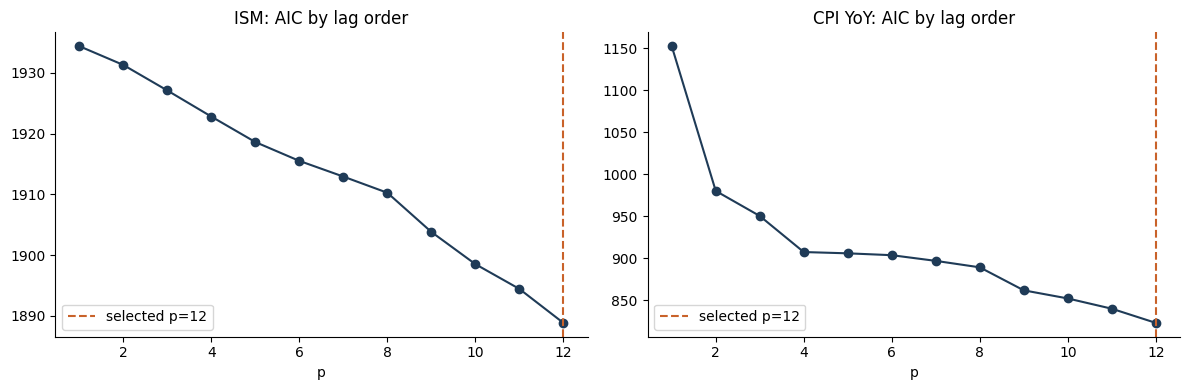

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(ism_order_table["p"], ism_order_table["aic"], marker="o", color="#1f3b57")
axes[0].axvline(ism_p, color="#c9622a", ls="--", label=f"selected p={ism_p}")
axes[0].set_title("ISM: AIC by lag order"); axes[0].set_xlabel("p"); axes[0].legend()

axes[1].plot(yoy_order_table["p"], yoy_order_table["aic"], marker="o", color="#1f3b57")
axes[1].axvline(yoy_p, color="#c9622a", ls="--", label=f"selected p={yoy_p}")
axes[1].set_title("CPI YoY: AIC by lag order"); axes[1].set_xlabel("p"); axes[1].legend()
plt.tight_layout(); plt.show()


## 4. Fit on the full sample & forecast forward

Fit each AR(p) on the complete history, then forecast 12 months ahead
(recursive, i.e. each forecasted value feeds the next month's lag) so we can
read off the 6-9 month-ahead window specifically.


In [ ]:
HORIZON = 12

def fit_and_forecast(series, p, horizon=HORIZON):
    model = AutoReg(series, lags=p).fit()
    fc = model.forecast(steps=horizon)
    fc.index = pd.date_range(series.index[-1] + pd.offsets.MonthEnd(1), periods=horizon, freq="ME")
    return model, fc

ism_model, ism_fc = fit_and_forecast(ism, ism_p)
yoy_model, yoy_fc = fit_and_forecast(cpi_yoy, yoy_p)

print(ism_model.summary())


                            AutoReg Model Results                             
Dep. Variable:                    ism   No. Observations:                  348
Model:                    AutoReg(12)   Log Likelihood                -930.428
Method:               Conditional MLE   S.D. of innovations              3.507
Date:                Mon, 21 Sep 2026   AIC                           1888.855
Time:                        21:14:07   BIC                           1942.786
Sample:                    09-30-1997   HQIC                          1910.326
                         - 08-31-2026                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         10.7360      2.056      5.222      0.000       6.706      14.766
ism.L1         0.8868      0.053     16.603      0.000       0.782       0.991
ism.L2        -0.0792      0.072     -1.108      0.2

In [ ]:
print(yoy_model.summary())


                            AutoReg Model Results                             
Dep. Variable:                    cpi   No. Observations:                  932
Model:                    AutoReg(12)   Log Likelihood                -397.442
Method:               Conditional MLE   S.D. of innovations              0.371
Date:                Mon, 21 Sep 2026   AIC                            822.883
Time:                        21:14:07   BIC                            890.606
Sample:                    01-31-1949   HQIC                           848.710
                         - 08-31-2026                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0873      0.021      4.236      0.000       0.047       0.128
cpi.L1         1.3698      0.032     42.243      0.000       1.306       1.433
cpi.L2        -0.3750      0.055     -6.816      0.0

In [ ]:
# translate the CPI YoY forecast back into an implied CPI level path:
# CPI_t = CPI_(t-12) * (1 + YoY_t / 100)
def cpi_level_from_yoy(cpi_level_hist, yoy_fc):
    combined = cpi_level_hist.copy()
    out = {}
    for date, yoy_val in yoy_fc.items():
        base_date = (date - pd.DateOffset(years=1)) + pd.offsets.MonthEnd(0)
        base_val = combined.get(base_date, combined.iloc[-12])
        level = base_val * (1 + yoy_val / 100)
        combined.loc[date] = level
        out[date] = level
    return pd.Series(out)

cpi_level_fc = cpi_level_from_yoy(cpi, yoy_fc)


### Forecast charts

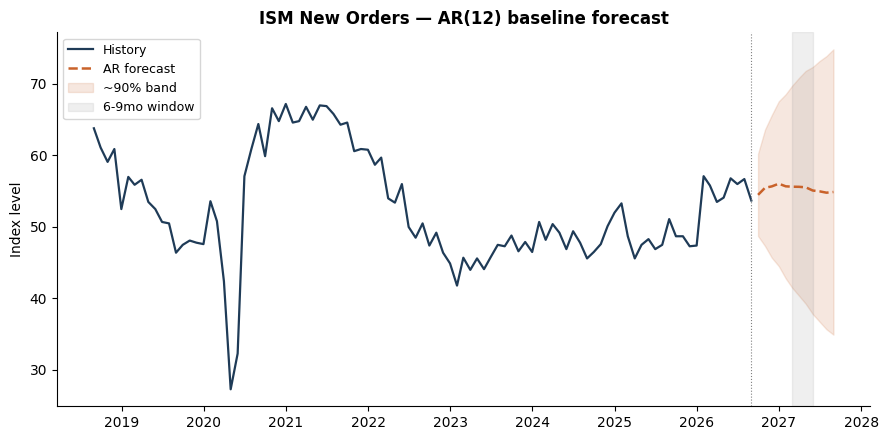

In [ ]:
def plot_forecast(hist, fc, resid_std, title, ylabel, hist_years=8):
    fig, ax = plt.subplots()
    h = hist[hist.index >= hist.index[-1] - pd.DateOffset(years=hist_years)]
    ax.plot(h.index, h.values, color="#1f3b57", lw=1.6, label="History")
    ax.plot(fc.index, fc.values, color="#c9622a", lw=1.8, ls="--", label="AR forecast")
    steps = np.arange(1, len(fc) + 1)
    band = resid_std * np.sqrt(steps)
    ax.fill_between(fc.index, fc.values - 1.64*band, fc.values + 1.64*band,
                     color="#c9622a", alpha=0.15, label="~90% band")
    if len(fc) >= 9:
        ax.axvspan(fc.index[5], fc.index[8], color="gray", alpha=0.12, label="6-9mo window")
    ax.axvline(hist.index[-1], color="gray", lw=0.8, ls=":")
    ax.set_title(title, fontweight="bold"); ax.set_ylabel(ylabel); ax.legend(fontsize=9)
    plt.tight_layout(); plt.show()

plot_forecast(ism, ism_fc, ism_model.resid.std(),
              f"ISM New Orders — AR({ism_p}) baseline forecast", "Index level")


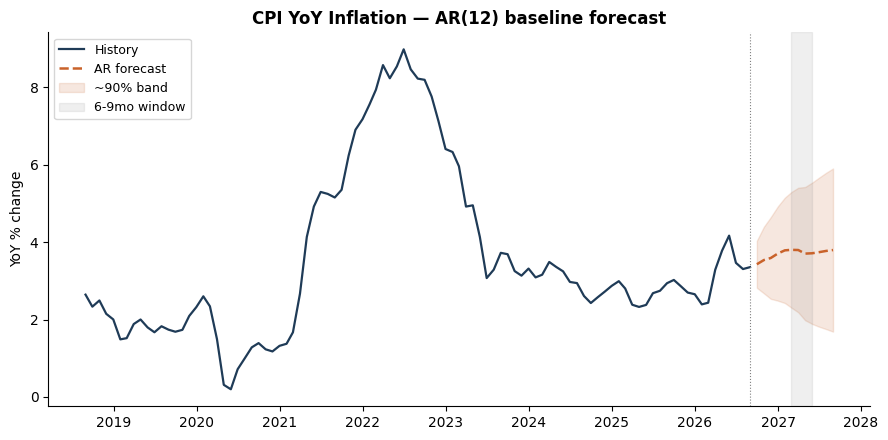

In [ ]:
plot_forecast(cpi_yoy, yoy_fc, yoy_model.resid.std(),
              f"CPI YoY Inflation — AR({yoy_p}) baseline forecast", "YoY % change")


### 6-9 month-ahead forecast table

In [ ]:
window = ism_fc.index[5:9]  # months-ahead 6,7,8,9
summary = pd.DataFrame({
    "months_ahead": range(1, HORIZON + 1),
    "ISM_forecast": ism_fc.values,
    "CPI_YoY_forecast_%": yoy_fc.values,
    "CPI_level_implied": cpi_level_fc.values,
}, index=ism_fc.index.strftime("%Y-%m"))
summary.index.name = "month"

def highlight_window(row):
    return ["background-color: #fde9dc" if row["months_ahead"] in (6,7,8,9) else "" for _ in row]

summary.style.apply(highlight_window, axis=1)


,months_ahead,ISM_forecast,CPI_YoY_forecast_%,CPI_level_implied
month,,,,
2026-09,1,54.490242,3.427720,335.359211
2026-10,2,55.478810,3.536605,336.135731
2026-11,3,55.673891,3.588875,336.729105
2026-12,4,56.049174,3.703817,338.106592
2027-01,5,55.683891,3.786793,338.955212
2027-02,6,55.631416,3.800031,339.903581
2027-03,7,55.614833,3.795497,342.829262
2027-04,8,55.541837,3.702604,344.714715
2027-05,9,55.097099,3.711449,346.374460


## 5. Train/test split & out-of-sample RMSE

We hold out the **last 20%** of each series chronologically as the test set.

In [ ]:
TEST_FRAC = 0.20

def train_test_split(series, test_frac=TEST_FRAC):
    n_test = int(round(len(series) * test_frac))
    return series.iloc[:-n_test], series.iloc[-n_test:]

def walk_forward_backtest(series, max_lag=MAX_LAG, test_frac=TEST_FRAC, max_horizon=HORIZON):
    train, test = train_test_split(series, test_frac)
    p, order_table = select_order(train, max_lag)

    # one-step-ahead walk-forward
    history = train.copy()
    actuals, preds = [], []
    for date in test.index:
        m = AutoReg(history, lags=p).fit()
        preds.append(m.forecast(steps=1).iloc[0])
        actuals.append(series.loc[date])
        history = pd.concat([history, series.loc[[date]]])
    actuals = pd.Series(actuals, index=test.index)
    preds = pd.Series(preds, index=test.index)
    rmse_1step = float(np.sqrt(np.mean((actuals - preds) ** 2)))

    # horizon-specific rolling-origin RMSE
    horizon_errors = {h: [] for h in range(1, max_horizon + 1)}
    full_index = series.index
    test_start_pos = len(train)
    for origin_pos in range(test_start_pos, len(full_index)):
        origin_date = full_index[origin_pos]
        hist_up_to_origin = series.loc[:origin_date].iloc[:-1]
        if len(hist_up_to_origin) < p + 1:
            continue
        m = AutoReg(hist_up_to_origin, lags=p).fit()
        max_h = min(max_horizon, len(full_index) - origin_pos)
        if max_h < 1:
            continue
        fc = m.forecast(steps=max_h)
        for h in range(1, max_h + 1):
            actual = series.iloc[origin_pos + h - 1]
            pred = fc.iloc[h - 1]
            horizon_errors[h].append((actual - pred) ** 2)
    horizon_rmse = {h: (float(np.sqrt(np.mean(e))) if e else np.nan) for h, e in horizon_errors.items()}

    return {"p": p, "train": train, "test": test, "actuals": actuals, "preds": preds,
            "rmse_1step": rmse_1step, "horizon_rmse": horizon_rmse}

ism_bt = walk_forward_backtest(ism)
yoy_bt = walk_forward_backtest(cpi_yoy)

print(f"ISM      -- train {len(ism_bt['train'])} / test {len(ism_bt['test'])} obs, AR({ism_bt['p']}) on train")
print(f"  1-step-ahead test RMSE: {ism_bt['rmse_1step']:.3f}")
print(f"CPI YoY  -- train {len(yoy_bt['train'])} / test {len(yoy_bt['test'])} obs, AR({yoy_bt['p']}) on train")
print(f"  1-step-ahead test RMSE: {yoy_bt['rmse_1step']:.3f}")


ISM      -- train 288 / test 72 obs, AR(12) on train
  1-step-ahead test RMSE: 2.810
CPI YoY  -- train 755 / test 189 obs, AR(12) on train
  1-step-ahead test RMSE: 0.321


### Backtest chart: test-period actuals vs. 1-step-ahead forecasts

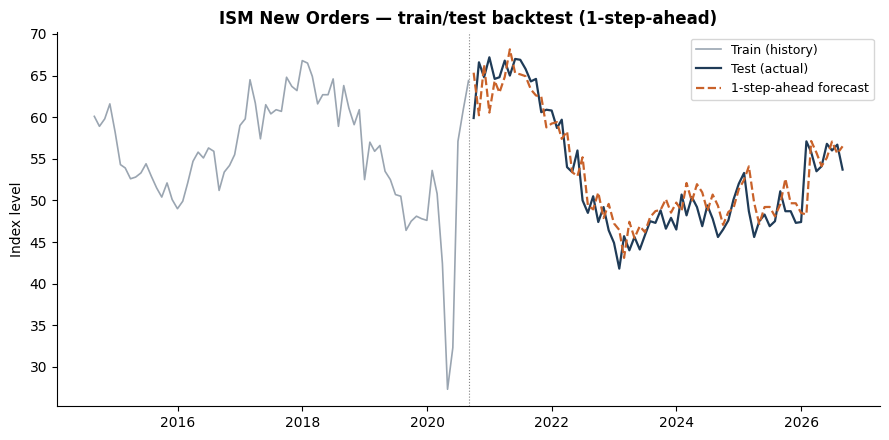

In [ ]:
def plot_backtest(train, test, actuals, preds, title, ylabel, hist_years=6):
    fig, ax = plt.subplots()
    h = train[train.index >= train.index[-1] - pd.DateOffset(years=hist_years)]
    ax.plot(h.index, h.values, color="#9aa5b1", lw=1.2, label="Train (history)")
    ax.plot(test.index, test.values, color="#1f3b57", lw=1.6, label="Test (actual)")
    ax.plot(preds.index, preds.values, color="#c9622a", lw=1.6, ls="--", label="1-step-ahead forecast")
    ax.axvline(train.index[-1], color="gray", lw=0.8, ls=":")
    ax.set_title(title, fontweight="bold"); ax.set_ylabel(ylabel); ax.legend(fontsize=9)
    plt.tight_layout(); plt.show()

plot_backtest(ism_bt["train"], ism_bt["test"], ism_bt["actuals"], ism_bt["preds"],
              "ISM New Orders — train/test backtest (1-step-ahead)", "Index level")


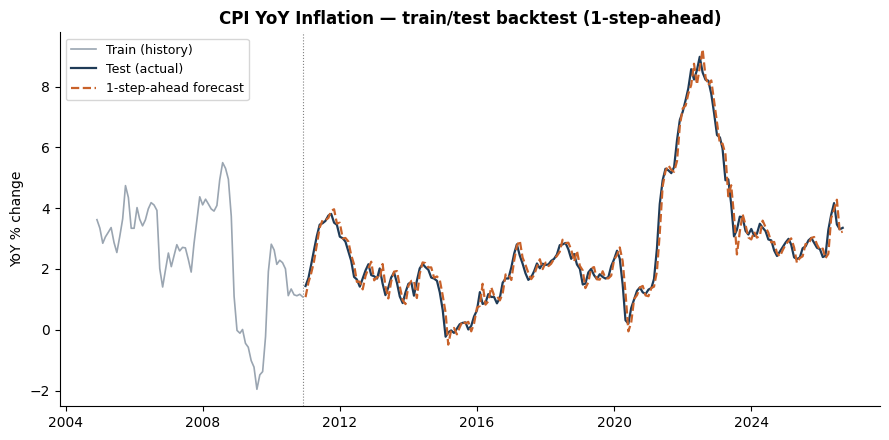

In [ ]:
plot_backtest(yoy_bt["train"], yoy_bt["test"], yoy_bt["actuals"], yoy_bt["preds"],
              "CPI YoY Inflation — train/test backtest (1-step-ahead)", "YoY % change")


### RMSE by forecast horizon (the 6-9 month window is what matters here)

In [ ]:
horizon_df = pd.DataFrame({
    "months_ahead": range(1, HORIZON + 1),
    "ISM_RMSE": [ism_bt["horizon_rmse"][h] for h in range(1, HORIZON + 1)],
    "CPI_YoY_RMSE": [yoy_bt["horizon_rmse"][h] for h in range(1, HORIZON + 1)],
}).set_index("months_ahead")

def highlight_window(row):
    return ["background-color: #fde9dc" if row.name in (6,7,8,9) else "" for _ in row]

horizon_df.style.apply(highlight_window, axis=1).format("{:.3f}")


,ISM_RMSE,CPI_YoY_RMSE
months_ahead,,
1,2.810,0.321
2,3.413,0.563
3,4.034,0.747
4,4.582,0.892
5,4.990,1.019
6,5.431,1.142
7,5.801,1.251
8,6.073,1.366
9,6.397,1.490


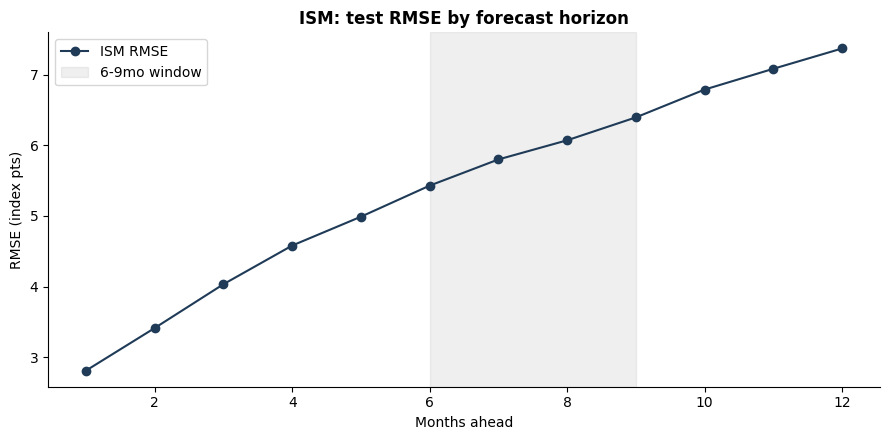

In [ ]:
fig, ax = plt.subplots()
ax.plot(horizon_df.index, horizon_df["ISM_RMSE"], marker="o", color="#1f3b57", label="ISM RMSE")
ax.axvspan(6, 9, color="gray", alpha=0.12, label="6-9mo window")
ax.set_xlabel("Months ahead"); ax.set_ylabel("RMSE (index pts)")
ax.set_title("ISM: test RMSE by forecast horizon", fontweight="bold"); ax.legend()
plt.tight_layout(); plt.show()


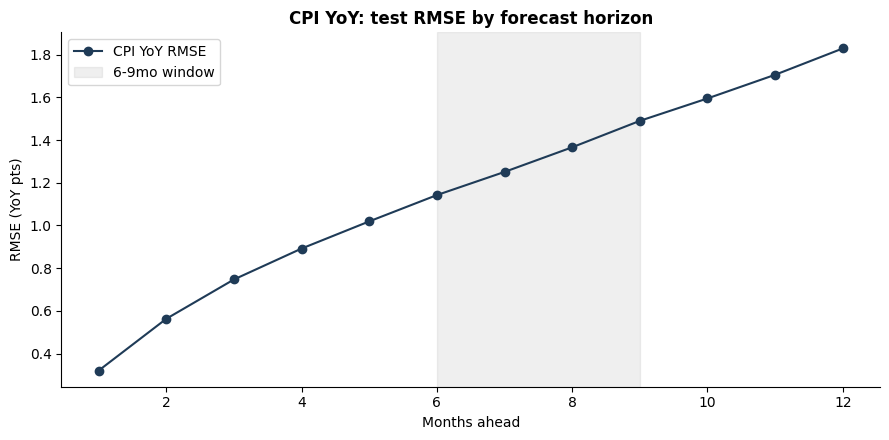

In [ ]:
fig, ax = plt.subplots()
ax.plot(horizon_df.index, horizon_df["CPI_YoY_RMSE"], marker="o", color="#1f3b57", label="CPI YoY RMSE")
ax.axvspan(6, 9, color="gray", alpha=0.12, label="6-9mo window")
ax.set_xlabel("Months ahead"); ax.set_ylabel("RMSE (YoY pts)")
ax.set_title("CPI YoY: test RMSE by forecast horizon", fontweight="bold"); ax.legend()
plt.tight_layout(); plt.show()
